# Auditoría de licencias: ¿qué se anuncia sin licencia válida?

Este notebook responde a la pregunta central de **[M-08]** en `docs/prd.md`: hasta qué punto se puede identificar la oferta anunciada que **no tiene licencia válida**.

La diferencia con `02_exploracion_airbnb.ipynb` es el paso decisivo: allí se audita si el anuncio **declara** algo en el campo `license`; aquí se comprueba si lo que declara **existe de verdad en el registro oficial**.

## Dos precauciones antes de empezar

**1. Declarar una licencia no es tenerla, pero no declararla tampoco es carecer de ella.** El campo lo rellena el anfitrión: puede estar mal escrito, desactualizado o simplemente vacío en un alojamiento perfectamente legal.

**2. No toda la oferta necesita licencia VUT.** Una habitación en la vivienda habitual, un alquiler de temporada de 32+ noches o un hotel se rigen por regímenes distintos. Contar "anuncios sin HUTB" como "anuncios ilegales" sería un error de bulto.

Por eso el resultado se etiqueta siempre como **candidato**, nunca como infracción — coherente con el WON'T de `docs/prd.md`.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path('../..')
pd.set_option('display.max_columns', None)

airbnb = pd.read_csv(RAIZ / 'data/raw/airbnb/insideairbnb_barcelona_2026-06-24_listings.csv')
vut = pd.read_csv(RAIZ / 'data/processed/vut_unificados.csv', dtype=str)

print(f'Anuncios de Airbnb          : {len(airbnb):,}')
print(f'Licencias VUT en el registro: {len(vut):,}')

Anuncios de Airbnb          : 15,406
Licencias VUT en el registro: 24,075


## 1. Cómo se lee el campo `license` (y por qué es fácil equivocarse)

El campo contiene **dos** números distintos, y confundirlos cambia el resultado por completo.

In [2]:
ejemplo = airbnb.loc[airbnb['license'].astype(str).str.contains('Regional', na=False), 'license'].iloc[0]
for linea in str(ejemplo).split('<br />'):
    if linea.strip():
        print(' |', linea.strip())

 | Spain - National registration number
 | ESFCTU000008058000039706000000000000000HUTB-002062349
 | Barcelona - Regional registration number
 | HUTB-002062


El número nacional (`ESFCTU...HUTB-002062349`) **incrusta** el HUTB y le añade dígitos de control. El bueno es el de la sección *Barcelona - Regional registration number*: `HUTB-002062`.

> Una expresión regular que busque `HUTB-\d+` en todo el campo captura el número nacional y da un HUTB inexistente. En una primera versión de este análisis ese error inflaba las licencias "no encontradas" del **14,8% al 36,2%**. Merece la pena verificar el parseo antes de creerse ningún porcentaje.

In [3]:
PATRON_REGIONAL = re.compile(
    r'Barcelona\s*-\s*Regional registration number\s*(?:<br\s*/?>)*\s*([^<]*)', re.I
)


def leer_licencia(texto):
    """Devuelve (numero_hutb, motivo_exencion) leyendo SOLO la sección regional."""
    if not isinstance(texto, str):
        return None, None
    encontrado = PATRON_REGIONAL.search(texto)
    if not encontrado:
        return None, None
    valor = encontrado.group(1).strip()
    if re.match(r'^Exempt', valor, re.I):
        return None, re.sub(r'^Exempt\s*-\s*', '', valor, flags=re.I).strip().lower()
    hutb = re.match(r'^HUTB[-\s]*(\d+)', valor, re.I)
    return (int(hutb.group(1)) if hutb else None), None


leido = airbnb['license'].apply(leer_licencia)
airbnb['hutb_num'] = [r[0] for r in leido]
airbnb['exencion'] = [r[1] for r in leido]
airbnb['hutb'] = airbnb['hutb_num'].apply(lambda n: f'HUTB-{int(n):06d}' if pd.notna(n) else None)

print(f"Declaran un HUTB   : {airbnb['hutb'].notna().sum():,}")
print(f"Declaran exención  : {airbnb['exencion'].notna().sum():,}")
print(f"No declaran nada   : {(airbnb['hutb'].isna() & airbnb['exencion'].isna()).sum():,}")

Declaran un HUTB   : 7,228
Declaran exención  : 2,960
No declaran nada   : 5,218


## 2. Contraste contra el registro oficial

El paso que responde a la pregunta: de los que declaran un HUTB, ¿cuántos existen realmente?

In [4]:
oficiales = set(vut.loc[vut['licencia_id'].str.match(r'^HUTB-\d+$', na=False), 'licencia_id'])
num_maximo = max(int(c.split('-')[1]) for c in oficiales)

airbnb['licencia_existe'] = airbnb['hutb'].isin(oficiales)
declaran = airbnb[airbnb['hutb'].notna()]

print(f'Licencias VUT oficiales distintas : {len(oficiales):,}')
print(f'Número oficial más alto           : {num_maximo:,}\n')
print(f'Anuncios que declaran HUTB        : {len(declaran):,}')
print(f'  existe en el registro           : {declaran["licencia_existe"].sum():,} ({declaran["licencia_existe"].mean():.1%})')
print(f'  NO existe                       : {(~declaran["licencia_existe"]).sum():,} ({(~declaran["licencia_existe"]).mean():.1%})')

Licencias VUT oficiales distintas : 22,801
Número oficial más alto           : 80,024

Anuncios que declaran HUTB        : 7,228
  existe en el registro           : 6,160 (85.2%)
  NO existe                       : 1,068 (14.8%)


### ¿Son errores o números inventados?

Un número por encima del más alto que ha emitido la Generalitat no puede ser un simple error de tecleo.

In [5]:
no_existen = declaran[~declaran['licencia_existe']].copy()
fuera_de_rango = no_existen['hutb_num'] > num_maximo

print(f'HUTB declarados que no constan: {len(no_existen):,}')
print(f'  fuera del rango emitido (> {num_maximo:,}): {fuera_de_rango.sum():,}  → imposible que existan')
print(f'  dentro del rango                        : {(~fuera_de_rango).sum():,}  → error, baja o discrepancia')
print('\nEjemplos de números fuera de rango:')
print(sorted(no_existen.loc[fuera_de_rango, 'hutb_num'].astype(int).unique())[-10:])

HUTB declarados que no constan: 1,068
  fuera del rango emitido (> 80,024): 889  → imposible que existan
  dentro del rango                        : 179  → error, baja o discrepancia

Ejemplos de números fuera de rango:
[np.int64(973421), np.int64(973555), np.int64(984910), np.int64(985436), np.int64(987000), np.int64(987654), np.int64(987890), np.int64(988770), np.int64(990666), np.int64(995187)]


## 3. Clasificación por situación regulatoria

Aquí está el matiz que evita el titular fácil: no todo anuncio necesita un HUTB. Se clasifica cada uno según lo que declara **y** según si por su naturaleza estaría sujeto al régimen VUT.

- **Vivienda completa con estancia mínima ≤ 31 noches** → es el supuesto que exige licencia VUT.
- **Estancia mínima ≥ 32 noches** → alquiler de temporada, fuera del régimen VUT.
- **Habitación privada o compartida** → régimen distinto (*llar compartida*), no HUTB.

In [6]:
def clasificar(fila):
    if pd.notna(fila['hutb']):
        return 'licencia_verificada' if fila['licencia_existe'] else 'licencia_no_encontrada'
    if pd.notna(fila['exencion']):
        return 'exencion_declarada'
    return 'sin_declarar'


airbnb['situacion'] = airbnb.apply(clasificar, axis=1)

# ¿Está sujeto al régimen VUT por su propia naturaleza?
airbnb['sujeto_a_vut'] = (
    (airbnb['room_type'] == 'Entire home/apt') & (airbnb['minimum_nights'] <= 31)
)

resumen = airbnb['situacion'].value_counts().to_frame('anuncios')
resumen['%'] = (resumen['anuncios'] / len(airbnb) * 100).round(1)
resumen

,anuncios,%
situacion,,
licencia_verificada,6160,40.0
sin_declarar,5218,33.9
exencion_declarada,2960,19.2
licencia_no_encontrada,1068,6.9


In [7]:
tabla = pd.crosstab(airbnb['situacion'], airbnb['sujeto_a_vut'])
tabla.columns = ['No sujeto (habitación o 32+ noches)', 'Sujeto a licencia VUT']
tabla

,No sujeto (habitación o 32+ noches),Sujeto a licencia VUT
situacion,,
exencion_declarada,1931,1029
licencia_no_encontrada,547,521
licencia_verificada,154,6006
sin_declarar,3778,1440


## 4. El resultado: candidatos a operar sin licencia

Se cuentan solo los anuncios que **están sujetos al régimen VUT** y aun así no acreditan una licencia válida. Es la cifra defendible; cualquier número mayor estaría contando alojamientos con otro régimen legal.

In [8]:
sujetos = airbnb[airbnb['sujeto_a_vut']]
candidatos = sujetos[sujetos['situacion'].isin(['sin_declarar', 'licencia_no_encontrada'])]

print(f'Anuncios totales                        : {len(airbnb):,}')
print(f'Sujetos al régimen VUT                  : {len(sujetos):,}')
print(f'  con licencia verificada               : {(sujetos["situacion"] == "licencia_verificada").sum():,}')
print(f'  con exención declarada                : {(sujetos["situacion"] == "exencion_declarada").sum():,}')
print()
print(f'CANDIDATOS a operar sin licencia válida : {len(candidatos):,}')
print(f'  ({len(candidatos) / len(sujetos):.1%} de los sujetos al régimen VUT)')
print()
print('Desglose:')
print(candidatos['situacion'].value_counts().to_string())

Anuncios totales                        : 15,406
Sujetos al régimen VUT                  : 8,996
  con licencia verificada               : 6,006
  con exención declarada                : 1,029

CANDIDATOS a operar sin licencia válida : 1,961
  (21.8% de los sujetos al régimen VUT)

Desglose:
situacion
sin_declarar              1440
licencia_no_encontrada     521


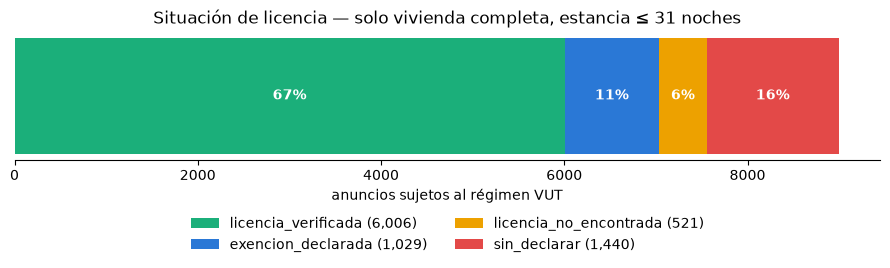

In [9]:
orden = ['licencia_verificada', 'exencion_declarada', 'licencia_no_encontrada', 'sin_declarar']
datos = sujetos['situacion'].value_counts().reindex(orden).fillna(0)
colores = ['#1baf7a', '#2a78d6', '#eda100', '#e34948']

fig, ax = plt.subplots(figsize=(9, 3.2))
izquierda = 0
for etiqueta, valor, color in zip(orden, datos, colores):
    ax.barh(0, valor, left=izquierda, color=color, label=f'{etiqueta} ({int(valor):,})')
    if valor > 300:
        ax.text(izquierda + valor / 2, 0, f'{valor / datos.sum():.0%}',
                ha='center', va='center', color='white', fontweight='bold')
    izquierda += valor

ax.set_yticks([])
ax.set_xlabel('anuncios sujetos al régimen VUT')
ax.set_title('Situación de licencia — solo vivienda completa, estancia ≤ 31 noches')
ax.legend(bbox_to_anchor=(0.5, -0.35), loc='upper center', ncol=2, frameon=False)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)
plt.tight_layout()

## 5. ¿Dónde se concentran los candidatos?

In [10]:
por_distrito = pd.DataFrame({
    'sujetos': sujetos.groupby('neighbourhood_group').size(),
    'candidatos': candidatos.groupby('neighbourhood_group').size(),
}).fillna(0).astype(int)
por_distrito['% candidatos'] = (por_distrito['candidatos'] / por_distrito['sujetos'] * 100).round(1)
por_distrito.sort_values('candidatos', ascending=False)

,sujetos,candidatos,% candidatos
neighbourhood_group,,,
Eixample,3869,706,18.2
Ciutat Vella,1370,474,34.6
Sant Martí,885,212,24.0
Sants-Montjuïc,946,173,18.3
Gràcia,859,154,17.9
Sarrià-Sant Gervasi,511,128,25.0
Horta-Guinardó,193,41,21.2
Les Corts,192,41,21.4
Sant Andreu,88,19,21.6


El **porcentaje** importa más que el valor absoluto: un distrito con mucha oferta tendrá muchos candidatos aunque su tasa de irregularidad sea baja.

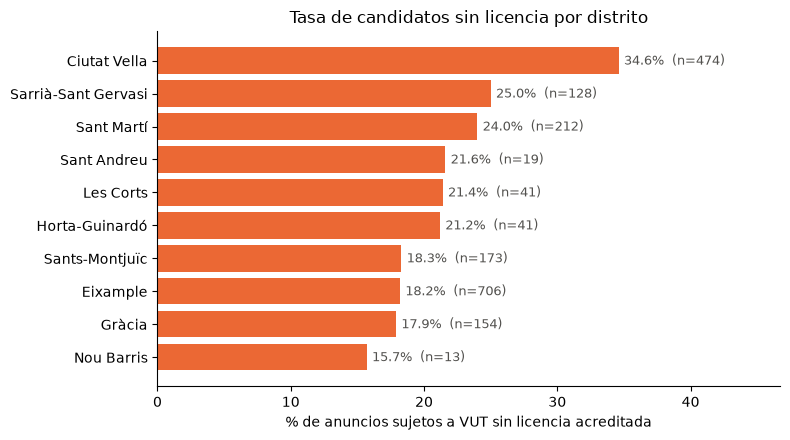

In [11]:
orden_pct = por_distrito.sort_values('% candidatos')
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(orden_pct.index, orden_pct['% candidatos'], color='#eb6834')
for i, (pct, n) in enumerate(zip(orden_pct['% candidatos'], orden_pct['candidatos'])):
    ax.text(pct + 0.4, i, f'{pct}%  (n={n:,})', va='center', fontsize=9, color='#52514e')
ax.set_xlabel('% de anuncios sujetos a VUT sin licencia acreditada')
ax.set_title('Tasa de candidatos sin licencia por distrito')
ax.set_xlim(0, orden_pct['% candidatos'].max() * 1.35)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
plt.tight_layout()

## 6. ¿Quién está detrás? Anfitriones con varios candidatos

Un particular que alquila su piso sin saber que necesita licencia es un caso distinto de quien gestiona varios sin acreditar ninguno.

In [12]:
por_host = candidatos.groupby(['host_id', 'host_name']).size().sort_values(ascending=False)
print(f'Anfitriones distintos con algún candidato: {len(por_host):,}')
print(f'  con 1 solo anuncio : {(por_host == 1).sum():,}')
print(f'  con 2 o más        : {(por_host >= 2).sum():,}')
print(f'  con 5 o más        : {(por_host >= 5).sum():,}')
print(f'\nAnuncios candidatos en manos de anfitriones con 5+: {por_host[por_host >= 5].sum():,}')
print('\nTop 10 (nombre de anfitrión tal como lo publica Airbnb):')
por_host.head(10).to_frame('anuncios candidatos')

Anfitriones distintos con algún candidato: 754
  con 1 solo anuncio : 591
  con 2 o más        : 163
  con 5 o más        : 56

Anuncios candidatos en manos de anfitriones con 5+: 1,092

Top 10 (nombre de anfitrión tal como lo publica Airbnb):


,,anuncios candidatos
host_id,host_name,
346367515.0,Ukio,352
1447144.0,Acomodis Apartments,117
21726991.0,Silvia De Lourdes,103
32037490.0,Sweett,58
64805231.0,Marc,32
397090058.0,Caterina,31
250042982.0,Miki,31
234256283.0,Francesc,18
396363.0,Alcam Apartments,18


## 7. La dirección contraria: licencias sin anuncio en Airbnb

También interesa el reverso — licencias oficiales de la ciudad que no aparecen anunciadas aquí. **No es un indicio de nada irregular**: pueden estar en Booking u otras plataformas, alquiladas por temporadas, o sencillamente vacías. Sirve para dimensionar qué parte del parque legal se ve en Airbnb.

In [13]:
vut_ciudad = vut[(vut['municipio'] == 'Barcelona') & vut['licencia_id'].str.match(r'^HUTB-\d+$', na=False)]
anunciadas = set(declaran.loc[declaran['licencia_existe'], 'hutb'])
en_airbnb = vut_ciudad['licencia_id'].isin(anunciadas)

print(f'Licencias VUT en la ciudad de Barcelona : {len(vut_ciudad):,}')
print(f'  visibles en Airbnb                    : {en_airbnb.sum():,} ({en_airbnb.mean():.1%})')
print(f'  sin anuncio en Airbnb                 : {(~en_airbnb).sum():,} ({(~en_airbnb).mean():.1%})')

Licencias VUT en la ciudad de Barcelona : 10,654
  visibles en Airbnb                    : 5,233 (49.1%)
  sin anuncio en Airbnb                 : 5,421 (50.9%)


## Conclusiones y límites

**Lo que sí se puede afirmar**

- El cruce con el registro oficial es viable y da un resultado utilizable: la mayoría de anuncios que declaran licencia la tienen de verdad.
- Hay un grupo de licencias declaradas **numéricamente imposibles** (por encima del último número emitido). Ahí no cabe el error de tecleo como explicación.
- Los candidatos se concentran de forma desigual por distrito, y una parte está en manos de anfitriones con varios anuncios.

**Lo que NO se puede afirmar**

- Que un candidato sea ilegal. El campo lo rellena el anfitrión y no hay obligación técnica de acertar; una licencia real mal escrita cae en este grupo.
- Que la lista sea exhaustiva. Solo cubre Airbnb: Booking y el resto quedan fuera (ver `docs/roadmap.md`).
- Nada a nivel de vivienda concreta. Inside Airbnb desplaza las coordenadas unos 200 m, así que el cruce es agregado por barrio o distrito, nunca anuncio contra dirección.

**Siguiente paso para [M-08]:** llevar esta clasificación a `pipeline/transform/` como script, para que el dashboard consuma la columna `situacion` ya calculada en vez de recalcularla.